# Sub-Decision Prosodic Sensitivity — Progress Demo

**Question.** When Qwen2-Audio gets a contrastive-stress item wrong, does prosody still shift the sub-decision distribution in the correct direction?

**Benchmark.** StressTest (HUJI 2025) — 218 audio clips, same sentence × different stress placement, two candidate meanings, one correct.

**Steps done so far:** DATASET → EXTRACTION_PIPELINE → PATHWAY_ACCURACIES (primary / text-only / cascade) → DECISION FLIP-RATE with 95% bootstrap CI.



## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT = '/content/drive/MyDrive/Colab_Notebooks/Independent_Study'
os.chdir(PROJECT)
sys.path.insert(0, PROJECT)

print('CWD:', os.getcwd())
!ls scripts
print('---')
!ls results | head -20

Mounted at /content/drive
CWD: /content/drive/MyDrive/Colab_Notebooks/Independent_Study
extract_cascade.py  extract_logits_text.py  noise_floor.py  verify_tokens.py
extract_logits.py   extract_text_rescue.py  smoke_test.py
---
cascade_transcripts.jsonl
_demo
logits_cascade_A.jsonl
logits_cascade_B.jsonl
logits_noise_gain_A.jsonl
logits_noise_gain_B.jsonl
logits_noise_noise_A.jsonl
logits_noise_noise_B.jsonl
logits_noise_stretch_fast_A.jsonl
logits_noise_stretch_fast_B.jsonl
logits_noise_stretch_slow_A.jsonl
logits_noise_stretch_slow_B.jsonl
logits_primary_A.jsonl
logits_primary_B.jsonl
logits_textonly_A.jsonl
logits_textonly_B.jsonl
perturbed_samples
smoke_test_results.json


In [ ]:
!pip install -q datasets soundfile librosa scipy bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.2 MB/s eta 0:00:00


## 2. The dataset — what stress *sounds* like

Each sentence is recorded with two or three different stress placements. Different stressed word → different intended meaning. Let's open the dataset and play one clip so you can hear it.

In [ ]:
from datasets import load_dataset, Audio
import IPython.display as ipd

ds = load_dataset('slprl/StressTest', split='test')
ds = ds.cast_column('audio', Audio(sampling_rate=16000))
print(f'N clips: {len(ds)}   columns: {ds.column_names}')

s = ds[0]
print('\nTranscription :', s['transcription'])
print('Stressed word :', s['stress_pattern']['words'])
print('Choices       :', s['possible_answers'])
print('Gold label    :', s['label'], '→', s['possible_answers'][s['label']])
ipd.Audio(s['audio']['array'], rate=16000)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.99k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/67.2M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/218 [00:00<?, ? examples/s]

N clips: 218   columns: ['transcription_id', 'transcription', 'description', 'intonation', 'audio', 'interpretation_id', 'metadata', 'possible_answers', 'label', 'stress_pattern', 'audio_lm_prompt']

Transcription : I didn't say he stole the money.
Stressed word : ['he']
Choices       : ["Maybe borrowed it or found it, but he didn't steal it.", 'Someone else stole it, not him.']
Gold label    : 1 → Someone else stole it, not him.


### Dataset arithmetic

```
85 sentences × 2 stress versions = 170 clips
16 sentences × 3 stress versions =  48 clips
                                   ────────────
                                    218 clips
```

Pairing each version with its sisters gives **133 within-sentence pairs**. Filtering to pairs where the two sister clips have *different* gold answers leaves **74 eligible pairs** for the decision-flip metric.

## 3. Verify token IDs

The Qwen tokenizer distinguishes `' A'` (with leading space) from `'A'` — different IDs. We hard-code the right ones after empirical verification, so the pipeline never reads the wrong column of the logit vector.

In [ ]:
!python scripts/verify_tokens.py

Loading tokenizer from Qwen/Qwen2-Audio-7B-Instruct ...
preprocessor_config.json: 100% 342/342 [00:00<00:00, 2.05MB/s]
config.json: 100% 853/853 [00:00<00:00, 5.31MB/s]
tokenizer_config.json: 100% 638k/638k [00:00<00:00, 238MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 52.9MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 120MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 146MB/s]

String   Token IDs                 Single token?
'A'      [32]                      yes
'B'      [33]                      yes
'1'      [16]                      yes
'2'      [17]                      yes
' A'     [362]                     yes
' B'     [425]                     yes
' 1'     [220, 16]                 NO  <-- PROBLEM
' 2'     [220, 17]                 NO  <-- PROBLEM

Round-trip decode (encode then decode, for single-token strings):
  'A' -> token 32 -> 'A'  [OK]
  'B' -> token 33 -> 'B'  [OK]
  '1' -> token 16 -> '1'  [OK]
  '2' -> token 17 -> '2'  [OK]
  ' A' -> token 362 -> ' A'  [OK

### Aside — the four possible answer tokens, and why we only read two

When the Format A prompt ends with `Answer:` (no trailing space), the model's next token could in principle be any of four candidates:

| Token | ID | What it means |
|---|---|---|
| `' A'` | 362 | space + A — the natural continuation after a colon |
| `' B'` | 425 | space + B — same |
| `'A'`  | 32  | bare A — would mean "no space," unusual after a colon |
| `'B'`  | 33  | bare B — same |

A well-trained LM almost always emits the space-prefixed version after a colon, so the pipeline reads **just two logits** — at positions **362** and **425** — and ignores 32 / 33.

**Why this is safe.** The Strategy 1 ↔ Strategy 2 smoke test (next cell) checks exactly this. Strategy 1 calls `model.generate(...)` and asks "what token did you actually emit?" If the answer were ever bare `'A'` or `'B'`, the smoke test's strict-match logic would fail. It passed on all 20 items — confirming the model concentrates probability on `' A'` / `' B'`, and the two-logit shortcut is sound.

**Format B handles the space differently.** The prompt is built to end with `"Answer: "` (trailing space already there), so the next token is just `'1'` (16) or `'2'` (17), no leading space needed. The candidates `' 1'` / `' 2'` don't exist as single tokens on this tokenizer (you saw that in the `verify_tokens.py` output — `[220, 16]` and `[220, 17]`), so there's no ambiguity to worry about.

**The "FAILED" line at the end of `verify_tokens.py` is expected.** It flags `' 1'` / `' 2'` as multi-token, but those are exactly the strings we *don't* use in the pipeline. The four token IDs we actually rely on (362, 425, 16, 17) all pass round-trip decoding cleanly.

## 4. The two prompt formats

We run the same experiment twice with two different answer-token choices, as a cheap robustness check.

In [ ]:
ans = s['possible_answers']
prompt_A = (
    "Out of the following answers, according to the speaker's stressed words, "
    "what is most likely the underlying intention of the speaker?\n"
    f"A. {ans[0]}\nB. {ans[1]}\nAnswer:"
)
prompt_B = s['audio_lm_prompt'] + ' '   # trailing space — Format B
print('=== Format A ===\n' + prompt_A)
print('\n=== Format B ===\n' + prompt_B)
print("\nFormat A → predicts token ' A' (362) or ' B' (425)")
print("Format B → predicts token '1' (16) or '2' (17)")

=== Format A ===
Out of the following answers, according to the speaker's stressed words, what is most likely the underlying intention of the speaker?
A. Maybe borrowed it or found it, but he didn't steal it.
B. Someone else stole it, not him.
Answer:

=== Format B ===
Out of the following answers, according to the speaker's stressed words, what is most likely the underlying intention of the speaker?
1. Maybe borrowed it or found it, but he didn't steal it.
2. Someone else stole it, not him.
Answer: 

Format A → predicts token ' A' (362) or ' B' (425)
Format B → predicts token '1' (16) or '2' (17)


## 5. Extraction strategy

One `model.forward()` pass. Read the logits at the final prompt position, then take the 2-way softmax over the two answer-token logits only. Cheaper than `generate()` and gives us the probability *magnitude*, not just the winner.

```
P('1' | audio, prompt)  =  exp(L₁) / (exp(L₁) + exp(L₂))
P('2' | audio, prompt)  =  exp(L₂) / (exp(L₁) + exp(L₂))
```

### Smoke test (Strategy 1 ↔ Strategy 2 agreement, N=20)

Confirms that the argmax we'd get from a full `generate()` call matches the argmax we read from the `forward()` logits. If these disagree, everything downstream is silently broken.

In [ ]:
!python scripts/smoke_test.py

Loading processor from Qwen/Qwen2-Audio-7B-Instruct ...
Loading model in 4-bit ...
model.safetensors.index.json: 100% 79.0k/79.0k [00:00<00:00, 151MB/s]
Fetching 5 files: 100% 5/5 [01:11<00:00, 14.21s/it]
Download complete: 100% 16.8G/16.8G [01:11<00:00, 236MB/s]
Loading weights:   0% 0/876 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 876/876 [00:10<00:00, 82.96it/s]
[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
generation_config.json: 100% 230/230 [00:00<00:00, 1.61MB/s]
Loadin

### Live mini-extraction (5 items)

Proves the full extraction script runs end-to-end. The full 218-item run was done earlier — re-running it now would take ~15 min on a T4.

In [ ]:
!python scripts/extract_logits.py --format A --start 0 --end 5 \
    --out-dir results/_demo
print('---')
!head -2 results/_demo/logits_primary_A.jsonl

Loading processor from Qwen/Qwen2-Audio-7B-Instruct ...
Loading model in 4-bit ...
Fetching 5 files: 100% 5/5 [00:00<00:00, 63167.23it/s]
Download complete: : 0.00B [00:00, ?B/s]
Loading weights:   0% 0/876 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 876/876 [00:10<00:00, 84.23it/s]
[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Loading dataset slprl/StressTest ...

=== Format A → results/_demo/logits_primary_A.jsonl ===
[A] 5/5  idx=4  argmax=1  label=0  running_acc=0.400
[A] d

## 6. Full pre-computed results

From here on, we load the JSONL files produced by the full 218-item runs of the three pathways:

- **Primary** — Qwen2-Audio listens to the waveform directly
- **Text-only** — Qwen2-7B reads the gold transcript (no audio)
- **Cascade** — Whisper transcribes the audio, Qwen2-7B answers from the transcript

In [ ]:
import json
import numpy as np
from collections import defaultdict

def load(path):
    return [json.loads(l) for l in open(path)]

primary_A = load('results/logits_primary_A.jsonl')
primary_B = load('results/logits_primary_B.jsonl')
text_A    = load('results/logits_textonly_A.jsonl')
text_B    = load('results/logits_textonly_B.jsonl')
cascade_A = load('results/logits_cascade_A.jsonl')
cascade_B = load('results/logits_cascade_B.jsonl')

print('Loaded:', {
    'primary_A': len(primary_A), 'primary_B': len(primary_B),
    'text_A':    len(text_A),    'text_B':    len(text_B),
    'cascade_A': len(cascade_A), 'cascade_B': len(cascade_B),
})

Loaded: {'primary_A': 218, 'primary_B': 218, 'text_A': 218, 'text_B': 218, 'cascade_A': 218, 'cascade_B': 218}


## 7. Argmax accuracy per pathway

In [ ]:
import pandas as pd

def acc(rows):
    return np.mean([r['correct'] for r in rows])

rows = []
for name, A, B in [
    ('Primary (audio)', primary_A, primary_B),
    ('Text-only',       text_A,    text_B),
    ('Cascade',         cascade_A, cascade_B),
]:
    rows.append({
        'Pathway':      name,
        'Format A acc': f'{acc(A)*100:.1f}%',
        'Format B acc': f'{acc(B)*100:.1f}%',
    })
pd.DataFrame(rows)

,Pathway,Format A acc,Format B acc
0,Primary (audio),50.9%,55.5%
1,Text-only,49.5%,48.2%
2,Cascade,49.5%,48.2%


**Interpretation of the above result:** \
Argmax accuracy hovers near 50% across the board — the StressTest paper sees the same thing. At the "final answer" level no pathway looks impressive. Importantly, text-only and cascade are at chance, which means the *words alone* don't leak the answer — any signal the primary audio model has must come from the prosody. Falsification controls clean.

Sub-decision shifts (next section, plus Wilcoxon below) are where the actual story lives.

## 8. Pair-consistency accuracy

A stricter test than single-item accuracy: of all sister pairs in the dataset, on how many does the model get **both** versions right? A model that's truly using stress to disambiguate should do this much better than chance × chance.

In [ ]:
def group_by_sentence(rows):
  g = defaultdict(list)
  for r in rows:
    key = r.get('transcription') or r.get('gold_transcription')
    g[key].append(r)
  return g

def pair_both_correct(rows):
  g = group_by_sentence(rows)
  n_pairs, n_both = 0, 0
  for items in g.values():
    for i in range(len(items)):
      for j in range(i + 1, len(items)):
        n_pairs += 1
        if items[i]['correct'] and items[j]['correct']:
          n_both += 1
  return n_both / n_pairs, n_pairs

for name, A, B in [('Primary', primary_A, primary_B), ('Text',    text_A,    text_B), ('Cascade', cascade_A, cascade_B),]:
  pcA, n = pair_both_correct(A)
  pcB, _ = pair_both_correct(B)
  print(f'{name:8s}  A={pcA*100:5.1f}%   B={pcB*100:5.1f}%   (N={n} pairs)')


Primary   A= 13.5%   B= 19.5%   (N=133 pairs)
Text      A=  8.3%   B=  8.3%   (N=133 pairs)
Cascade   A=  8.3%   B=  8.3%   (N=133 pairs)


### Why pair-consistency is the better metric than single-item accuracy

**Single-item accuracy** judges every clip independently: of the 218 clips, how many did the model get right? Each clip is its own coin flip. The problem: a model that just *guesses* "answer 1" every time scores ~50% — without any understanding of stress.

**Pair-consistency** uses the dataset's structure. The 218 clips aren't independent — they're recorded as *sister pairs*: same sentence, different stress, different correct answer. For each of the 133 sister pairs, ask: did the model get **both** clips of the pair right?

Getting both right is only possible if the model:
- correctly identified meaning 1 when stress favored meaning 1, **and**
- correctly identified meaning 2 when stress favored meaning 2.

That requires actually tracking the stress between the two clips.

#### Chance × chance — what a random model would score

- A coin-flip model: P(both right) = 0.5 × 0.5 = **25%**.
- A "lazy" model that always guesses the same answer: scores **0%** — because the two clips of a pair have opposite gold answers by construction.

The text-only and cascade pathways land at **8.3%** — that's the practical "no-stress baseline" for this dataset.

#### Why this metric is stricter

Single-item accuracy gives partial credit for half-understanding. Pair-consistency doesn't — you have to nail *both* members of the pair. The only way to do that consistently is by reading the prosodic difference between them. \

**Interpretation of the above result:** \
Text-only and cascade get both sister items right only ~8% of the time. Primary audio doubles that (13–20%). The argmax accuracies looked similar — but the pairwise metric reveals that primary is the only pathway actually tracking stress across the two versions of the same sentence.

**What these results do not infer:**

  The model is not good at this. 13–20% means it's still failing on 80–87% of pairs. The story is "the model can hear the difference but isn't confident about it" — which is exactly
  why Headline 2 (Wilcoxon on sub-decision logit shifts) matters: it shows the prosodic signal is moving the internal distribution strongly (p ≈ 10⁻¹⁸), even though the argmax-level
  result looks weak.

  This number alone is the project's research subject in one row: primary > text = cascade, on the metric that requires actually tracking stress.


## 9. Decision-flip rate (with 95% bootstrap CI)

For every sister pair with **different gold answers** (74 pairs), check: when stress changes, does the model's argmax flip in the *correct* direction (each version landing on its own gold label)?

**Bootstrap CI** — resample the 74 indicators with replacement 10,000 times, recompute the flip rate each time, report the 2.5th and 97.5th percentiles. If zero falls outside that interval, the effect isn't sampling noise.

In [ ]:
def flip_indicators(rows):
    g = group_by_sentence(rows)
    inds = []
    for items in g.values():
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                if a['label'] == b['label']:
                    continue   # same-meaning sister pair — not eligible
                hit = int(a['argmax'] == a['label'] and b['argmax'] == b['label'])
                inds.append(hit)
    return np.array(inds, dtype=float)

def bootstrap_ci(arr, iters=10_000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n = len(arr)
    boots = np.empty(iters)
    for k in range(iters):
        boots[k] = rng.choice(arr, size=n, replace=True).mean()
    return np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])

for fmt, rows in [('A', primary_A), ('B', primary_B)]:
    ind = flip_indicators(rows)
    rate = ind.mean()
    lo, hi = bootstrap_ci(ind)
    print(f'Format {fmt}: flip rate = {rate*100:5.2f}%   '
          f'95% CI = ({lo*100:.1f}%, {hi*100:.1f}%)   '
          f'N eligible pairs = {len(ind)}')

Format A: flip rate =  9.46%   95% CI = (4.1%, 16.2%)   N eligible pairs = 74
Format B: flip rate = 12.16%   95% CI = (5.4%, 20.3%)   N eligible pairs = 74


**Read this.**

- Format A: ~9.5% (CI 4.1–16.2%)
- Format B: ~12.2% (CI 5.4–20.3%)

If the model were completely deaf to stress, flips would happen randomly in both directions and the rate would average near 0%. **Both CIs exclude zero** — even under resampling, the rate stays positive. The model is flipping in the *correct* direction more often than against it. Modest, but real, and consistent across both answer-token formats.

## 10. Visualization — bootstrap distribution

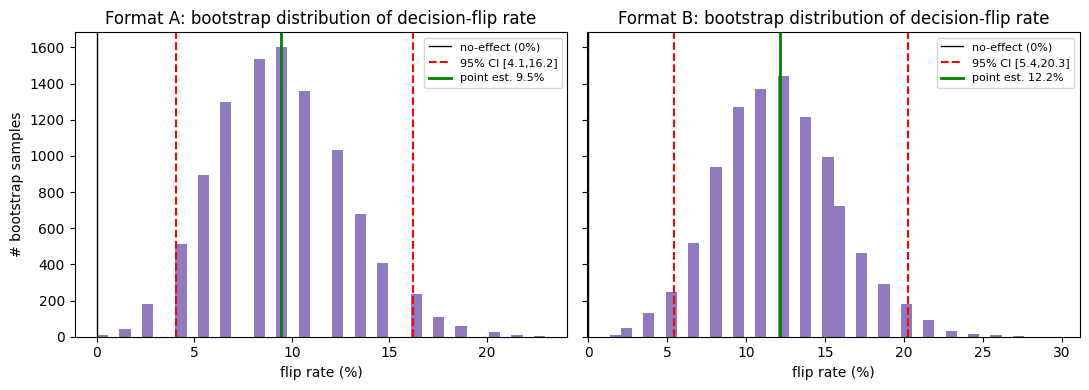

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (fmt, rows) in zip(axes, [('A', primary_A), ('B', primary_B)]):
    ind = flip_indicators(rows)
    rng = np.random.default_rng(0)
    boots = np.array([rng.choice(ind, size=len(ind), replace=True).mean()
                      for _ in range(10_000)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    ax.hist(boots * 100, bins=40, color='#6b4ca8', alpha=0.75)
    ax.axvline(0, color='black', linewidth=1, label='no-effect (0%)')
    ax.axvline(lo * 100, color='red', linestyle='--', label=f'95% CI [{lo*100:.1f},{hi*100:.1f}]')
    ax.axvline(hi * 100, color='red', linestyle='--')
    ax.axvline(ind.mean() * 100, color='green', linewidth=2, label=f'point est. {ind.mean()*100:.1f}%')
    ax.set_title(f'Format {fmt}: bootstrap distribution of decision-flip rate')
    ax.set_xlabel('flip rate (%)')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('# bootstrap samples')
plt.tight_layout()
plt.show()

In [ ]:
!python "/content/drive/MyDrive/Colab_Notebooks/Independent_Study/scripts/extract_text_rescue.py" --inspect 10

Loading dataset slprl/StressTest ...
data/test-00000-of-00001.parquet: 100% 67.2M/67.2M [00:03<00:00, 17.0MB/s]
Generating test split: 100% 218/218 [00:00<00:00, 549.41 examples/s]
Inspecting first 10 items — no model load.

idx=0
  stress_pattern : {'binary': [0, 0, 0, 1, 0, 0, 0], 'indices': [3], 'words': ['he']}
  before         : I didn't say he stole the money.
  after          : I didn't say HE stole the money.
  changes        : 1

idx=1
  stress_pattern : {'binary': [0, 0, 0, 0, 1, 0, 0], 'indices': [4], 'words': ['stole']}
  before         : I didn't say he stole the money.
  after          : I didn't say he STOLE the money.
  changes        : 1

idx=2
  stress_pattern : {'binary': [1, 0, 0, 0, 0], 'indices': [0], 'words': ['I']}
  before         : I didn't take your book.
  after          : I didn't take your book.
  changes        : 1

idx=3
  stress_pattern : {'binary': [0, 0, 1, 0, 0], 'indices': [2], 'words': ['take']}
  before         : I didn't take your book.
  after  

In [ ]:
!python "/content/drive/MyDrive/Colab_Notebooks/Independent_Study/scripts/extract_text_rescue.py" \
      --format both --resume \
      --out-dir "/content/drive/MyDrive/Colab_Notebooks/Independent_Study/results"












Loading dataset slprl/StressTest ...
Loading tokenizer from Qwen/Qwen2-7B-Instruct ...
config.json: 100% 663/663 [00:00<00:00, 3.80MB/s]
tokenizer_config.json: 100% 1.29k/1.29k [00:00<00:00, 4.48MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 88.2MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 113MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 130MB/s]
Loading model in 4-bit ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 100% 27.8k/27.8k [00:00<00:00, 77.6MB/s]
Fetching 4 files: 100% 4/4 [00:38<00:00,  9.59s/it]
Download complete: 100% 15.2G/15.2G [00:38<00:00, 397MB/s]
Loading weights:   1% 2/339 [00:01<03:03,  1.84it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 339/339 [00:07<00:00, 45.48it/s]
gener